In [1]:
import os, numpy as np

# Map model → its .npz file that holds predictions/ROC data
files = {
    "MultiModal_simple": "model_v1_predictions.npz",
    "Augmentation": "roc_data_augmentation.npz",
    "Augm+Attention": "roc_data_augmentation_attention.npz",
    "Transformer+Augm": "roc_data_transformer.npz",
    "ViT16+Augm": "roc_data_transformer_ViT-16.npz",
}

def summarize_npz(path):
    d = np.load(path, allow_pickle=True)
    print(f"\n=== {path} ===")
    print("Keys:", list(d.files))
    # Try to guess likely keys and show shapes
    candidates_true = [k for k in d.files if "true" in k.lower() or "label" in k.lower() or k.lower()=="y"]
    candidates_pred = [k for k in d.files if "pred" in k.lower() or "prob" in k.lower() or "score" in k.lower()]
    for k in candidates_true + candidates_pred:
        try:
            arr = d[k]
            print(f"  {k}: shape={arr.shape}, dtype={arr.dtype}")
        except Exception as e:
            print(f"  {k}: (could not read) -> {e}")
    d.close()

for model, fname in files.items():
    if not os.path.exists(fname):
        print(f"[MISSING] {model}: {fname} not found in current folder.")
    else:
        print(f"[OK] {model}: {fname}")
        summarize_npz(fname)

print("\n➡️ Note the exact keys that correspond to:")
print("   - y_true (ground-truth labels)")
print("   - y_pred_proba (predicted probabilities or scores)")
print("We’ll use those keys in Step 2 to compute AUC & F1 for the bubble chart.")

[OK] MultiModal_simple: model_v1_predictions.npz

=== model_v1_predictions.npz ===
Keys: ['y_test', 'y_score']
  y_score: shape=(237, 3), dtype=float32
[OK] Augmentation: roc_data_augmentation.npz

=== roc_data_augmentation.npz ===
Keys: ['fpr', 'tpr', 'roc_auc']
[OK] Augm+Attention: roc_data_augmentation_attention.npz

=== roc_data_augmentation_attention.npz ===
Keys: ['fpr', 'tpr', 'roc_auc']
[OK] Transformer+Augm: roc_data_transformer.npz

=== roc_data_transformer.npz ===
Keys: ['fpr', 'tpr', 'roc_auc']
[OK] ViT16+Augm: roc_data_transformer_ViT-16.npz

=== roc_data_transformer_ViT-16.npz ===
Keys: ['fpr', 'tpr', 'roc_auc']

➡️ Note the exact keys that correspond to:
   - y_true (ground-truth labels)
   - y_pred_proba (predicted probabilities or scores)
We’ll use those keys in Step 2 to compute AUC & F1 for the bubble chart.


In [2]:
import numpy as np

data = np.load("model_v1_predictions.npz", allow_pickle=True)
print(data.files)   # should show ['y_test', 'y_score']
print("y_test shape:", data["y_test"].shape)
print("y_score shape:", data["y_score"].shape)

['y_test', 'y_score']
y_test shape: (237,)
y_score shape: (237, 3)


In [3]:
from sklearn.metrics import roc_auc_score

y_true = data["y_test"]
y_score = data["y_score"]

auc_macro = roc_auc_score(y_true, y_score, multi_class="ovr", average="macro")
print("MultiModal_simple AUC (macro OVR):", auc_macro)

MultiModal_simple AUC (macro OVR): 0.9826230413874234


In [4]:
import numpy as np

d = np.load("roc_data_augmentation.npz", allow_pickle=True)
print("Keys:", list(d.files))           # should be ['fpr', 'tpr', 'roc_auc']

roc_auc = d["roc_auc"]
print("roc_auc raw type/shape:", type(roc_auc), getattr(roc_auc, "shape", None))

Keys: ['fpr', 'tpr', 'roc_auc']
roc_auc raw type/shape: <class 'numpy.ndarray'> ()


In [5]:
import numpy as np

roc_auc_dict = roc_auc.item()
if "macro" in roc_auc_dict:
    auc_augm = float(roc_auc_dict["macro"])
else:
    auc_augm = float(np.mean([float(v) for v in roc_auc_dict.values()]))

print("Augmentation AUC (macro):", auc_augm)

Augmentation AUC (macro): 0.986437468032216


In [6]:
import numpy as np

d = np.load("roc_data_augmentation_attention.npz", allow_pickle=True)
roc_auc = d["roc_auc"]                 # scalar object array holding a dict
roc_auc_dict = roc_auc.item()          # unwrap to dict
print("keys in roc_auc:", roc_auc_dict.keys())

# Prefer the provided macro if present (avoids double-averaging)
if "macro" in roc_auc_dict:
    auc_att = float(roc_auc_dict["macro"])
else:
    auc_att = float(np.mean([float(v) for v in roc_auc_dict.values()]))

print("Augm+Attention AUC (macro):", auc_att)
d.close()

keys in roc_auc: dict_keys([0, 1, 2, 'macro'])
Augm+Attention AUC (macro): 0.9720932745177782


In [7]:
import numpy as np

d = np.load("roc_data_transformer.npz", allow_pickle=True)
roc_auc = d["roc_auc"]
roc_auc_dict = roc_auc.item()      # unwrap dict
print("keys in roc_auc:", roc_auc_dict.keys())

if "macro" in roc_auc_dict:
    auc_trans = float(roc_auc_dict["macro"])
else:
    auc_trans = float(np.mean([float(v) for v in roc_auc_dict.values()]))

print("Transformer+Augm AUC (macro):", auc_trans)
d.close()

keys in roc_auc: dict_keys([0, 1, 2, 'macro'])
Transformer+Augm AUC (macro): 0.9868975472421246


In [8]:
import numpy as np

d = np.load("roc_data_transformer_ViT-16.npz", allow_pickle=True)
roc_auc = d["roc_auc"]
roc_auc_dict = roc_auc.item()       # unwrap dict
print("keys in roc_auc:", roc_auc_dict.keys())

if "macro" in roc_auc_dict:
    auc_vit = float(roc_auc_dict["macro"])
else:
    auc_vit = float(np.mean([float(v) for v in roc_auc_dict.values()]))

print("ViT16+Augm AUC (macro):", auc_vit)
d.close()

keys in roc_auc: dict_keys([0, 1, 2, 'macro'])
ViT16+Augm AUC (macro): 0.9888234147005701


In [15]:
!pip install "numpy<2" --upgrade --force-reinstall
!pip install --upgrade --force-reinstall matplotlib pandas scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 151.5 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 23.3.1 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 20.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 12.8 MB/s eta 0:00:00
     ━━━━━━

In [24]:
# === AUC–F1 Bubble Chart for your 5 models ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# ---- Paths ----
excel_path = "model_statistics_all.xlsx"
files = {
    "MModal_Baseline": "model_v1_predictions.npz",           # has y_test, y_score
    "MM-augmentation": "roc_data_augmentation.npz",          # has fpr,tpr,roc_auc
    "MM-attention": "roc_data_augmentation_attention.npz",   # has fpr,tpr,roc_auc
    "MM-transformer": "roc_data_transformer.npz",            # has fpr,tpr,roc_auc
    "MM-ViT16": "roc_data_transformer_ViT-16.npz",           # has fpr,tpr,roc_auc
}

In [25]:
# ---- Helpers to read AUC ----
def auc_from_predictions(npz_path):
    """Baseline model: has y_test and y_score."""
    d = np.load(npz_path, allow_pickle=True)
    y_true  = d["y_test"]
    y_score = d["y_score"]
    auc = roc_auc_score(y_true, y_score, multi_class="ovr", average="macro")
    d.close()
    return float(auc)

def auc_from_roc_npz(npz_path):
    """Other models: contain roc_auc dict or values."""
    d = np.load(npz_path, allow_pickle=True)
    roc_auc = d["roc_auc"]
    try:
        maybe = roc_auc.item()
        if isinstance(maybe, dict):
            if "macro" in maybe:   # prefer macro key
                val = float(maybe["macro"])
            else:
                val = float(np.mean([float(v) for v in maybe.values()]))
            d.close()
            return val
    except Exception:
        pass
    arr = np.array(roc_auc, dtype=float).ravel()
    d.close()
    return float(arr.mean())

def compute_auc(model_name, path):
    if model_name == "MModal_Baseline":
        return auc_from_predictions(path)
    else:
        return auc_from_roc_npz(path)

In [26]:
# ---- Compute AUCs ----
auc_rows = []
for m, p in files.items():
    auc_val = compute_auc(m, p)
    print(f"{m} AUC: {auc_val:.4f}")
    auc_rows.append({"Model": m, "AUC": auc_val})
auc_df = pd.DataFrame(auc_rows)

MModal_Baseline AUC: 0.9826
MM-augmentation AUC: 0.9864
MM-attention AUC: 0.9721
MM-transformer AUC: 0.9869
MM-ViT16 AUC: 0.9888


In [27]:
# ---- Load Excel robustly ----
tmp = pd.read_excel(excel_path, header=None)
header_row_idx = tmp.index[
    tmp.apply(lambda r: r.astype(str).str.contains(r"\bModel_ID\b", case=False, regex=True, na=False)).any(axis=1)
][0]
df = pd.read_excel(excel_path, header=header_row_idx)
df.columns = [str(c).strip() for c in df.columns]

In [28]:
# ---- Extract macro F1 ----
macro = df[df["Model_ID"].astype(str).str.lower().eq("macro avg")][["Model_Name","F1-score","Support"]].copy()
macro.rename(columns={"Model_Name":"Model","F1-score":"F1"}, inplace=True)

In [29]:
# Map Excel names -> your chosen display names
name_map = {
    "simple_CNN_multi": "MModal_Baseline",
    "augmentation_CNN_multi": "MM-augmentation",
    "att_augm_CNN_multi": "MM-attention",
    "transformer_augm_CNN_multi": "MM-transformer",
    "ViT16_augm_CNN_multi": "MM-ViT16",
}
macro["Model"] = macro["Model"].replace(name_map)
macro["Support"] = pd.to_numeric(macro["Support"], errors="coerce").fillna(237)

In [30]:
# ---- Merge AUC + F1 ----
metrics = pd.merge(auc_df, macro[["Model","F1","Support"]], on="Model", how="inner").sort_values("AUC")
print("\nFinal metrics table:\n", metrics)


Final metrics table:
              Model       AUC    F1  Support
2     MM-attention  0.972093  0.86    237.0
0  MModal_Baseline  0.982623  0.89    237.0
1  MM-augmentation  0.986437  0.87    237.0
3   MM-transformer  0.986898  0.91    237.0
4         MM-ViT16  0.988823  0.93    237.0


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

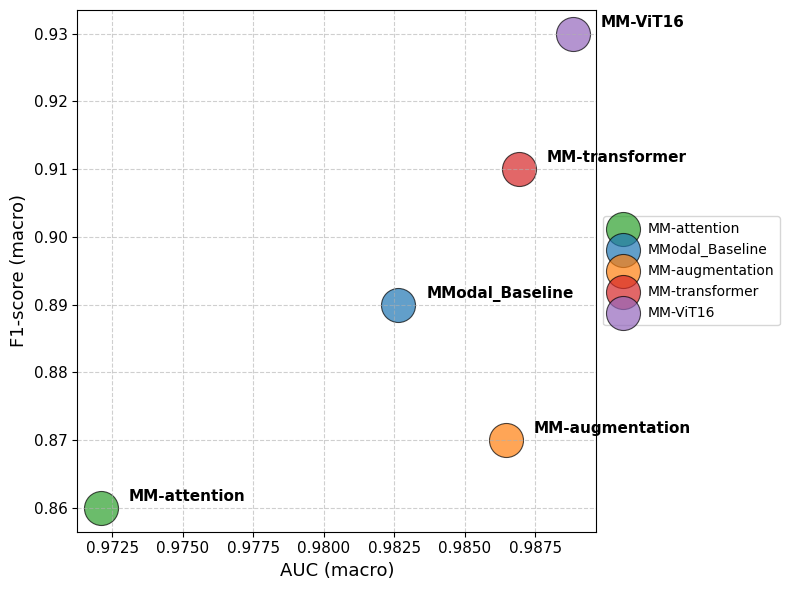

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# bubble sizes scaled by Support
sizes = metrics["Support"] / metrics["Support"].max() * 600

for i, r in metrics.iterrows():
    plt.scatter(r["AUC"], r["F1"], 
                s=sizes.iloc[i],   # FIXED: take size for this row only
                color=colors[r["Model"]], 
                alpha=0.7, edgecolor="black", linewidth=0.8, label=r["Model"])
    plt.text(r["AUC"]+0.001, r["F1"]+0.001, r["Model"], fontsize=11, weight="bold")

plt.xlabel("AUC (macro)", fontsize=13)
plt.ylabel("F1-score (macro)", fontsize=13)

plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# legend outside plot
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))  # avoid duplicates
plt.legend(by_label.values(), by_label.keys(), loc="center left", bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

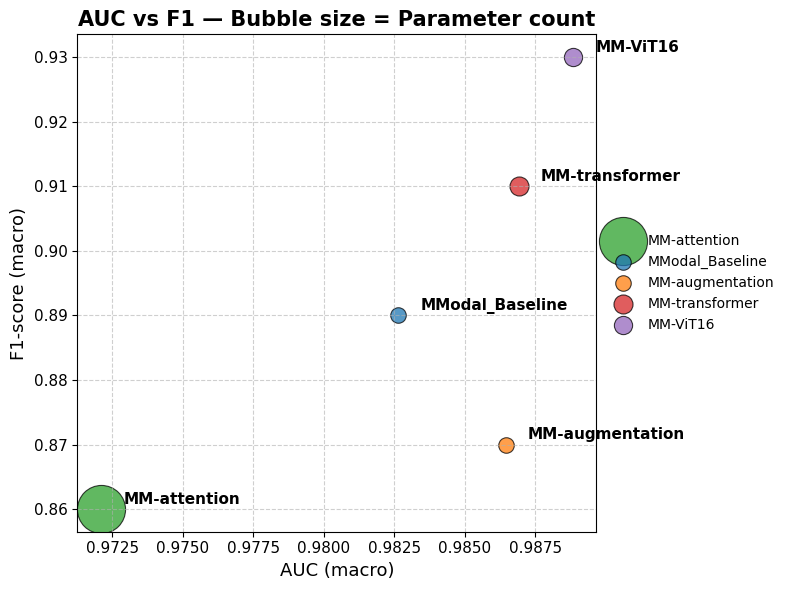

In [38]:
# === Add parameter counts to metrics and plot (bubble size = params) ===
param_counts = {
    "MModal_Baseline": 165_923,
    "MM-augmentation": 165_923,
    "MM-attention":   15_273_075,
    "MM-transformer": 373_667,
    "MM-ViT16":       315_011,
}

# Attach params
metrics["Params"] = metrics["Model"].map(param_counts)

# Drop rows with missing params (should be none now)
metrics = metrics.dropna(subset=["Params"]).reset_index(drop=True)

# Bubble size ~ sqrt(params) to avoid domination by huge models
sizes = (metrics["Params"] ** 0.5) / (metrics["Params"].max() ** 0.5) * 1200.0

# Colors per model (adjust if you already defined)
colors = {
    "MModal_Baseline": "#1f77b4",
    "MM-augmentation": "#ff7f0e",
    "MM-attention":   "#2ca02c",
    "MM-transformer": "#d62728",
    "MM-ViT16":       "#9467bd",
}

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
for i, r in metrics.iterrows():
    plt.scatter(r["AUC"], r["F1"],
                s=sizes.iloc[i],
                color=colors[r["Model"]],
                alpha=0.75, edgecolor="black", linewidth=0.8, label=r["Model"])
    plt.text(r["AUC"]+0.0008, r["F1"]+0.0008, r["Model"], fontsize=11, weight="bold")

plt.xlabel("AUC (macro)", fontsize=13)
plt.ylabel("F1-score (macro)", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(fontsize=11); plt.yticks(fontsize=11)

# Legend without duplicates
h, l = plt.gca().get_legend_handles_labels()
by_label = dict(zip(l, h))
plt.legend(by_label.values(), by_label.keys(), loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)

plt.tight_layout()
plt.show()

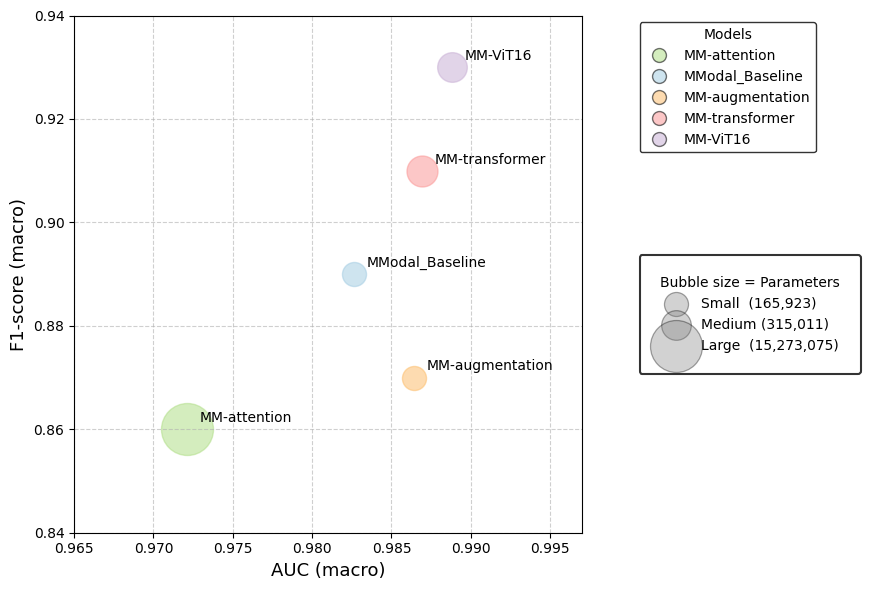

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- pastel colors ---
pastel_colors = {
    "MM-attention":    "#B2DF8A",  # pastel green
    "MModal_Baseline": "#A6CEE3",  # pastel blue
    "MM-augmentation": "#FDBF6F",  # pastel orange
    "MM-transformer":  "#FB9A99",  # pastel red
    "MM-ViT16":        "#CAB2D6",  # pastel purple
}

# --- bubble sizes from params (log scaling for clearer separation) ---
p = metrics["Params"].astype(float).values
p_min, p_max = p.min(), p.max()
# continuous log10 scale mapped to [300, 1400] points^2
sizes = ( (np.log10(p) - np.log10(p_min)) / (np.log10(p_max) - np.log10(p_min) + 1e-9) ) * (1400-300) + 300
sizes = pd.Series(sizes, index=metrics.index)

plt.figure(figsize=(9,6))

# plot points (alpha for transparency), labels placed NEXT to each bubble
for i, r in metrics.iterrows():
    plt.scatter(r["AUC"], r["F1"],
                s=sizes.loc[i],
                color=pastel_colors[r["Model"]],
                alpha=0.55)

    # small offset to the right/up so text sits next to the bubble
    plt.text(r["AUC"] + 0.0008, r["F1"] + 0.0008, r["Model"],
             ha="left", va="bottom", fontsize=10, color="black")

# axis ranges (keep yours; change if you like)
plt.xlim(0.965, 0.997)
plt.ylim(0.84, 0.94)
plt.xlabel("AUC (macro)", fontsize=13)
plt.ylabel("F1-score (macro)", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.6)

# ---------- legends ----------
# (A) Color legend (models)
color_handles = [
    Line2D([0],[0], marker='o', linestyle='', markersize=10,
           markerfacecolor=pastel_colors[m], markeredgecolor='black',
           alpha=0.55, label=m)
    for m in metrics["Model"]
]
leg1 = plt.legend(handles=color_handles, title="Models",
                  loc="upper left", bbox_to_anchor=(1.10, 1.0), frameon=True)
leg1.get_frame().set_edgecolor("black"); leg1.get_frame().set_linewidth(1.0)
plt.gca().add_artist(leg1)

# (B) Size legend (bubble size = params) with explicit numbers
# choose representative ticks: min / median / max (log-scaled to match plot)
ticks_params = np.array([p_min, np.median(p), p_max], dtype=float)
ticks_sizes  = ( (np.log10(ticks_params) - np.log10(p_min)) /
                 (np.log10(p_max) - np.log10(p_min) + 1e-9) ) * (1400-300) + 300
size_labels = [
    f"Small  ({int(ticks_params[0]):,})",
    f"Medium ({int(ticks_params[1]):,})",
    f"Large  ({int(ticks_params[2]):,})",
]
size_handles = [
    plt.scatter([], [], s=ticks_sizes[j], facecolor="gray", alpha=0.35,
                edgecolor="black", linewidth=0.9, label=size_labels[j])
    for j in range(3)
]
leg2 = plt.legend(handles=size_handles, title="Bubble size = Parameters",
                  loc="upper left", bbox_to_anchor=(1.10, 0.55), frameon=True, borderpad=1.5)
leg2.get_frame().set_edgecolor("black"); leg2.get_frame().set_linewidth(1.5)

plt.tight_layout()
plt.savefig("bubble_chart.pdf", format="pdf", bbox_inches="tight")  # save as vector PDF
plt.show()

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------- 1) Load Excel robustly --------------------
excel_path = "model_statistics_all.xlsx"  # <-- change if needed

tmp = pd.read_excel(excel_path, header=None)
# find the row containing the real header (Model_ID)
hdr_idx = tmp.index[
    tmp.apply(lambda r: r.astype(str).str.contains(r"\bModel_ID\b", case=False, regex=True, na=False)).any(axis=1)
][0]
df = pd.read_excel(excel_path, header=hdr_idx)
df.columns = [str(c).strip() for c in df.columns]

# Coerce numeric cols
for col in ["Precision","Recall","F1-score","Support","Total Params"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [66]:
# -------------------- 2) Name mapping & order --------------------
name_map = {
    "simple_CNN_multi":        "MModal_Baseline",
    "augmentation_CNN_multi":  "MM-augmentation",
    "att_augm_CNN_multi":      "MM-attention",
    "transformer_augm_CNN_multi":"MM-transformer",
    "ViT16_augm_CNN_multi":    "MM-ViT16",
}
model_order = ["MModal_Baseline","MM-augmentation","MM-attention","MM-transformer","MM-ViT16"]

# Pastel colors
colors = {
    "MModal_Baseline":"#A6CEE3",
    "MM-augmentation":"#FDBF6F",
    "MM-attention":"#B2DF8A",
    "MM-transformer":"#FB9A99",
    "MM-ViT16":"#CAB2D6",
}

Saved: radar_response.pdf and radar_response.png


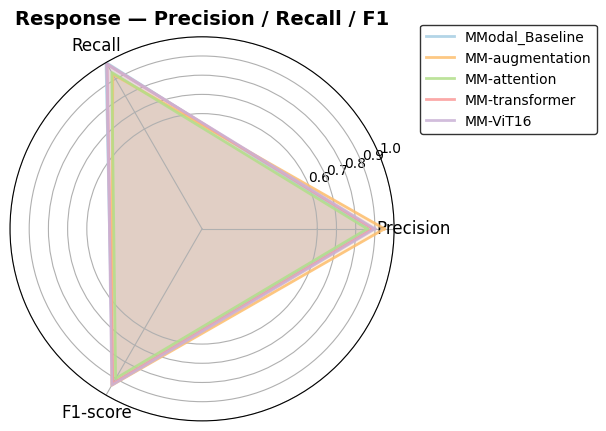

Saved: radar_stable.pdf and radar_stable.png


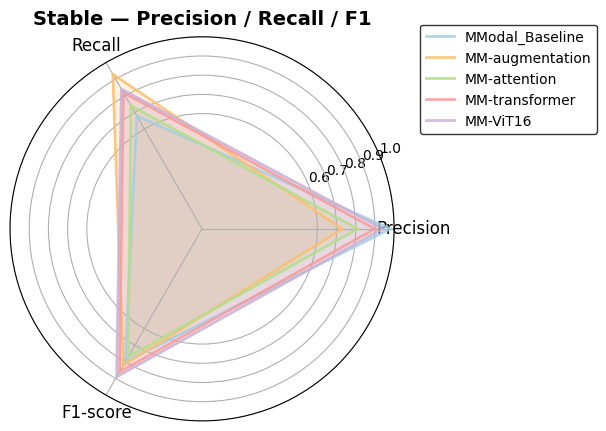

Saved: radar_non-response.pdf and radar_non-response.png


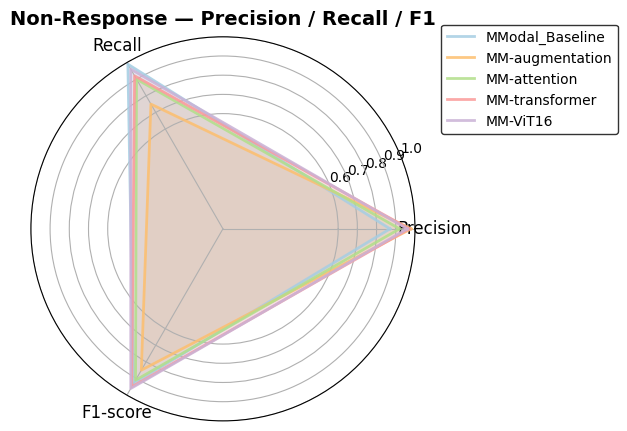

In [68]:
# -------------------- 3) Radar plot helper --------------------
def radar_plot_for_class(class_name, save=True):
    # filter rows for this class
    sub = df[df["Model_ID"].astype(str).str.strip().str.lower().eq(class_name.lower())].copy()
    if sub.empty:
        print(f"[warn] No rows found for class '{class_name}'")
        return

    # map model names and order
    sub["Model"] = sub["Model_Name"].replace(name_map)
    sub = sub[sub["Model"].isin(model_order)]
    sub = sub.set_index("Model").reindex(model_order).dropna(subset=["Precision","Recall","F1-score"], how="any")

    metrics = ["Precision","Recall","F1-score"]
    angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False)
    angles = np.concatenate([angles, angles[:1]])  # close the loop

    fig = plt.figure(figsize=(6.2,6.2))
    ax = plt.subplot(111, polar=True)
    ax.set_title(f"{class_name} — Precision / Recall / F1", va='bottom', fontsize=14, fontweight="bold")

    # radial ticks (0.6–1.0 is common for these metrics)
    ax.set_ylim(0.0, 1.0)
    ax.set_yticks([0.6, 0.7, 0.8, 0.9, 1.0])
    ax.set_yticklabels(["0.6","0.7","0.8","0.9","1.0"])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, fontsize=12)

    # plot each model
    for m in model_order:
        if m not in sub.index: 
            continue
        values = sub.loc[m, metrics].values.astype(float)
        values = np.concatenate([values, values[:1]])
        ax.plot(angles, values, color=colors[m], alpha=0.85, linewidth=2, label=m)
        ax.fill(angles, values, color=colors[m], alpha=0.20)

    # legend outside, framed
    leg = ax.legend(loc="upper left", bbox_to_anchor=(1.05, 1.05), frameon=True, fontsize=10)
    leg.get_frame().set_edgecolor("black"); leg.get_frame().set_linewidth(1.0)

    plt.tight_layout()
    if save:
        fname_pdf = f"radar_{class_name.replace(' ','_').lower()}.pdf"
        fname_png = f"radar_{class_name.replace(' ','_').lower()}.png"
        plt.savefig(fname_pdf, format="pdf", bbox_inches="tight")
        plt.savefig(fname_png, dpi=300, bbox_inches="tight")
        print(f"Saved: {fname_pdf} and {fname_png}")
    plt.show()

# -------------------- 4) Make one radar per class --------------------
for cls in ["Response","Stable","Non-Response"]:
    radar_plot_for_class(cls, save=True)

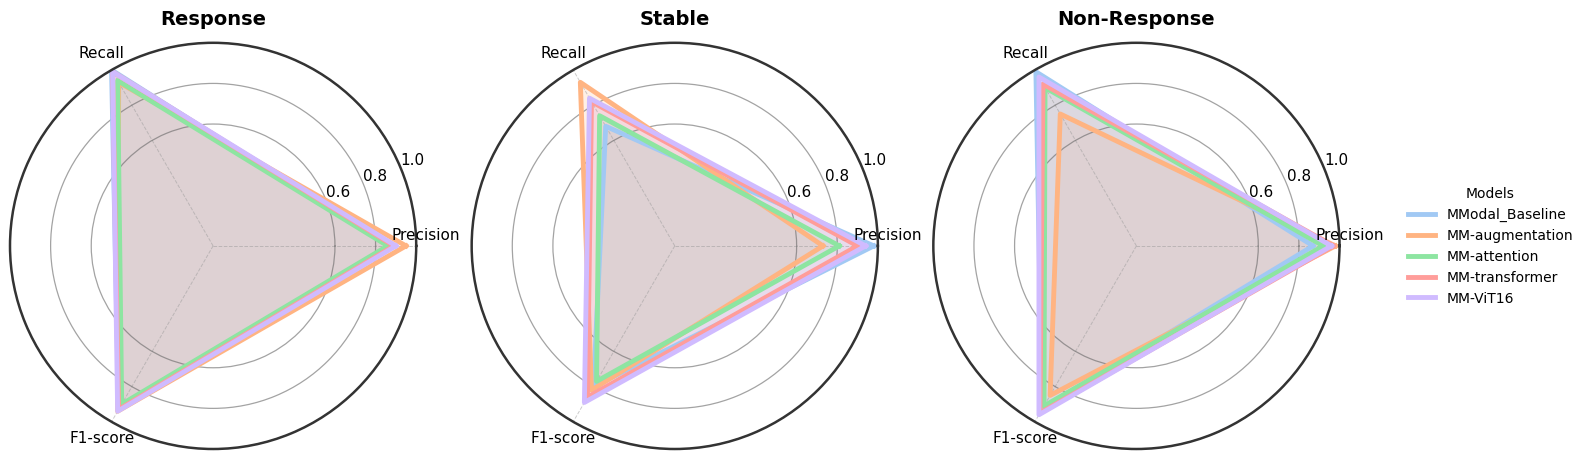

In [95]:
# -------- Map internal names -> display names (order controls legend) --------
name_map = {
    "simple_CNN_multi":         "MModal_Baseline",
    "augmentation_CNN_multi":   "MM-augmentation",
    "att_augm_CNN_multi":       "MM-attention",
    "transformer_augm_CNN_multi":"MM-transformer",
    "ViT16_augm_CNN_multi":     "MM-ViT16",
}
model_order = ["MModal_Baseline","MM-augmentation","MM-attention","MM-transformer","MM-ViT16"]

# Pastel palette (consistent across subplots)
colors = {
    "MModal_Baseline": "#a1c9f4",
    "MM-augmentation":  "#ffb482",
    "MM-attention":     "#8de5a1",
    "MM-transformer":   "#ff9d9a",
    "MM-ViT16":         "#d0bbff",
}

metrics = ["Precision","Recall","F1-score"]
angles  = np.linspace(0, 2*np.pi, len(metrics), endpoint=False)
angles  = np.concatenate([angles, angles[:1]])  # close loop
classes = ["Response","Stable","Non-Response"]

# -------- Figure: 1×3 with single legend to the right --------
fig, axes = plt.subplots(1, 3, figsize=(14, 5.2), subplot_kw=dict(polar=True))
fig.subplots_adjust(right=0.80, wspace=0.35)  # leave room for legend on the right

legend_handles = []
legend_labels  = []

for ax, cls in zip(axes, classes):
    sub = df[df["Model_ID"].astype(str).str.strip().str.lower().eq(cls.lower())].copy()
    sub["Model"] = sub["Model_Name"].replace(name_map)
    sub = sub[sub["Model"].isin(model_order)]
    sub = sub.set_index("Model").reindex(model_order)

    # ---- Radar plot styling (spider web) ----
    ax.set_title(cls, fontsize=14, fontweight="bold", pad=13)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.6","0.8","1.0"], fontsize=11)

    # spider-web custom style
    ax.spines["polar"].set_visible(True)
    ax.spines["polar"].set_edgecolor("#333333")
    ax.spines["polar"].set_linewidth(1.8)
    for gl in ax.yaxis.get_gridlines():
        gl.set_color("#666666")
        gl.set_linestyle("-")
        gl.set_linewidth(0.9)
        gl.set_alpha(0.6)
    for gl in ax.xaxis.get_gridlines():
        gl.set_color("#999999")
        gl.set_linestyle("--")
        gl.set_linewidth(0.7)
        gl.set_alpha(0.5)

    # ---- SHIFT "Precision" label slightly right ----
    ax.set_xticklabels(["", "Recall", "F1-score"])
    ax.text(angles[0] + 0.05, 1.05, "Precision",
            ha="center", va="center", fontsize=11)

    # ---- Plot each model ----
    for m in model_order:
        if m not in sub.index or sub.loc[m, metrics].isna().any():
            continue
        vals = sub.loc[m, metrics].astype(float).values
        vals = np.concatenate([vals, vals[:1]])
        ax.fill(angles, vals, color=colors[m], alpha=0.20)
        ln, = ax.plot(angles, vals, color=colors[m], linewidth=3.5, alpha=1.0, label=m)
        if not legend_labels or m not in legend_labels:
            legend_handles.append(ln); legend_labels.append(m)

# ---- Single legend on the right, centered vertically ----
leg = fig.legend(legend_handles, legend_labels,
                 loc="center left", bbox_to_anchor=(1.0, 0.5),
                 frameon=False, fontsize=10, title="Models")

plt.tight_layout()
plt.savefig("radar_panel_1x3.pdf", bbox_inches="tight")
plt.savefig("radar_panel_1x3.png", dpi=300, bbox_inches="tight")
plt.show()

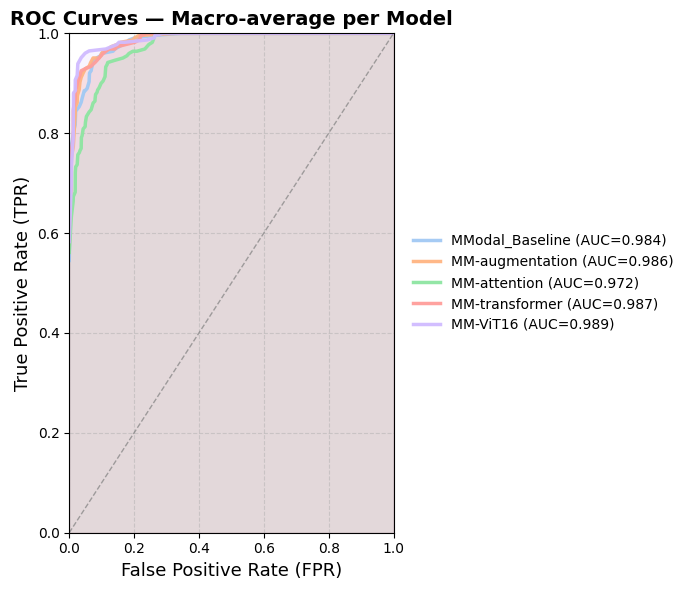

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# --- pastel consistent colors ---
colors = {
    "MModal_Baseline": "#a1c9f4",
    "MM-augmentation": "#ffb482",
    "MM-attention":    "#8de5a1",
    "MM-transformer":  "#ff9d9a",
    "MM-ViT16":        "#d0bbff",
}

# --- helpers ---
def macro_from_npz(npz_path):
    """Return fpr, tpr, auc (macro) from an .npz that already stores ROC data."""
    d = np.load(npz_path, allow_pickle=True)
    fpr = d["fpr"].item() if hasattr(d["fpr"], "item") else d["fpr"]
    tpr = d["tpr"].item() if hasattr(d["tpr"], "item") else d["tpr"]
    aucd= d["roc_auc"].item() if hasattr(d["roc_auc"], "item") else d["roc_auc"]
    return fpr["macro"], tpr["macro"], aucd["macro"]

def macro_from_scores(npz_path):
    """Return fpr, tpr, auc (macro) when only y_test and y_score are stored."""
    d = np.load(npz_path, allow_pickle=True)
    y_true = d["y_test"]
    y_prob = d["y_score"]

    classes = np.arange(y_prob.shape[1])
    Y = label_binarize(y_true, classes=classes)

    fpr, tpr, roc_auc = {}, {}, {}
    for i in classes:
        fpr[i], tpr[i], _ = roc_curve(Y[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Macro average
    all_fpr = np.unique(np.concatenate([fpr[i] for i in classes]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in classes:
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= len(classes)

    return all_fpr, mean_tpr, auc(all_fpr, mean_tpr)

# --- paths ---
files = {
    "MModal_Baseline": "model_v1_predictions.npz",           # has y_test, y_score
    "MM-augmentation": "roc_data_augmentation.npz",          # has fpr,tpr,roc_auc
    "MM-attention":    "roc_data_augmentation_attention.npz",
    "MM-transformer":  "roc_data_transformer.npz",
    "MM-ViT16":        "roc_data_transformer_ViT-16.npz",
}

# --- plot all in one ---
plt.figure(figsize=(7,6))

for name, path in files.items():
    if name == "MModal_Baseline":
        fpr, tpr, auc_macro = macro_from_scores(path)
    else:
        fpr, tpr, auc_macro = macro_from_npz(path)

    plt.plot(fpr, tpr, lw=2.5, color=colors[name],
             label=f"{name} (AUC={auc_macro:.3f})", alpha=0.95)
    # optional: pastel fill
    plt.fill_between(fpr, tpr, alpha=0.15, color=colors[name])

# Diagonal baseline
plt.plot([0,1],[0,1], color="gray", lw=1, linestyle="--", alpha=0.7)

plt.xlim(0,1); plt.ylim(0,1)
plt.xlabel("False Positive Rate (FPR)", fontsize=13)
plt.ylabel("True Positive Rate (TPR)", fontsize=13)
plt.title("ROC Curves — Macro-average per Model", fontsize=14, weight="bold")
plt.grid(True, linestyle="--", alpha=0.5)

plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=10)
plt.tight_layout()
plt.savefig("roc_all_models.pdf", bbox_inches="tight")
plt.show()

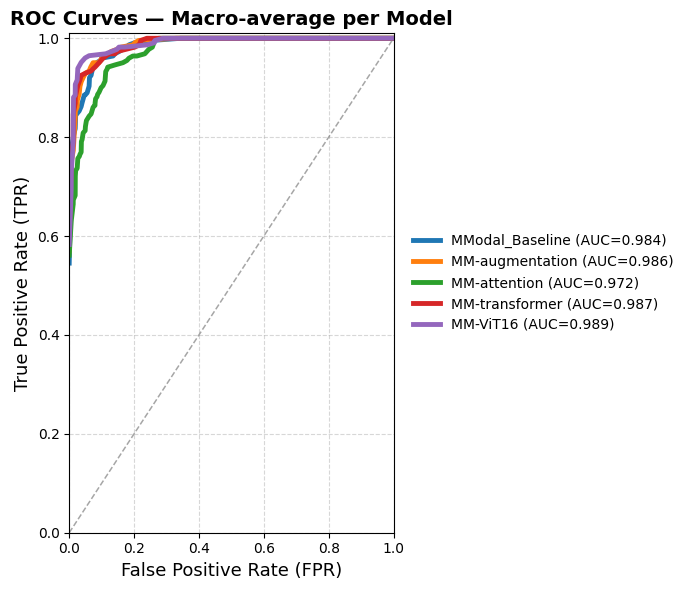

In [106]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# --- pastel consistent colors ---
colors = {
    "MModal_Baseline": "#1f77b4",  # darker blue
    "MM-augmentation": "#ff7f0e",  # darker orange
    "MM-attention":    "#2ca02c",  # darker green
    "MM-transformer":  "#d62728",  # darker red
    "MM-ViT16":        "#9467bd",  # darker purple
}

# --- helpers ---
def macro_from_npz(npz_path):
    d = np.load(npz_path, allow_pickle=True)
    fpr = d["fpr"].item() if hasattr(d["fpr"], "item") else d["fpr"]
    tpr = d["tpr"].item() if hasattr(d["tpr"], "item") else d["tpr"]
    aucd= d["roc_auc"].item() if hasattr(d["roc_auc"], "item") else d["roc_auc"]
    return fpr["macro"], tpr["macro"], aucd["macro"]

def macro_from_scores(npz_path):
    d = np.load(npz_path, allow_pickle=True)
    y_true = d["y_test"]
    y_prob = d["y_score"]

    classes = np.arange(y_prob.shape[1])
    Y = label_binarize(y_true, classes=classes)

    fpr, tpr, roc_auc = {}, {}, {}
    for i in classes:
        fpr[i], tpr[i], _ = roc_curve(Y[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    all_fpr = np.unique(np.concatenate([fpr[i] for i in classes]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in classes:
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= len(classes)

    return all_fpr, mean_tpr, auc(all_fpr, mean_tpr)

# --- paths ---
files = {
    "MModal_Baseline": "model_v1_predictions.npz",
    "MM-augmentation": "roc_data_augmentation.npz",
    "MM-attention":    "roc_data_augmentation_attention.npz",
    "MM-transformer":  "roc_data_transformer.npz",
    "MM-ViT16":        "roc_data_transformer_ViT-16.npz",
}

# --- plot all in one ---
plt.figure(figsize=(7,6))

for name, path in files.items():
    if name == "MModal_Baseline":
        fpr, tpr, auc_macro = macro_from_scores(path)
    else:
        fpr, tpr, auc_macro = macro_from_npz(path)

    plt.plot(fpr, tpr,
             lw=3.5,                 # thicker lines
             color=colors[name],
             label=f"{name} (AUC={auc_macro:.3f})",
             alpha=1.0)              # full opacity

# Diagonal baseline
plt.plot([0,1],[0,1], color="gray", lw=1.1, linestyle="--", alpha=0.7)

plt.xlim(0,1); plt.ylim(0,1.01)
plt.xlabel("False Positive Rate (FPR)", fontsize=13)
plt.ylabel("True Positive Rate (TPR)", fontsize=13)
plt.title("ROC Curves — Macro-average per Model", fontsize=14, weight="bold")
plt.grid(True, linestyle="--", alpha=0.5)

plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=10)
plt.tight_layout()
plt.savefig("roc_all_models.pdf", bbox_inches="tight")
plt.show()

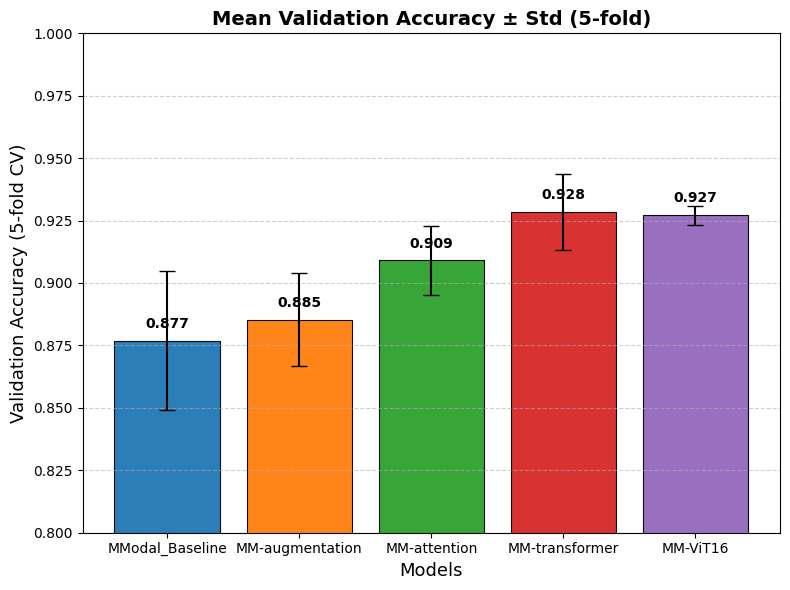

In [112]:
import pandas as pd
import matplotlib.pyplot as plt

excel_path = "model_statistics_all.xlsx"   # <-- adjust if needed

# Load robustly (handles "Table 1" header rows)
tmp = pd.read_excel(excel_path, header=None)

# Find the header row that contains "Model_ID"
hdr = tmp.index[
    tmp.apply(lambda r: r.astype(str).str.contains(r"\bModel_ID\b", na=False, case=False, regex=True), axis=1).any(axis=1)
][0]

df  = pd.read_excel(excel_path, header=hdr)
df.columns = [str(c).strip() for c in df.columns]

# Columns
mean_col = "Mean val accuracy (post-training 5fold)"
# std column is the one right after the mean accuracy col
std_col  = df.columns[df.columns.get_loc(mean_col) + 1]

# Keep only summary rows (models with mean val accuracy)
summary = df.dropna(subset=[mean_col]).copy()

# Map names
name_map = {
    "simple_CNN_multi":          "MModal_Baseline",
    "augmentation_CNN_multi":    "MM-augmentation",
    "att_augm_CNN_multi":        "MM-attention",
    "transformer_augm_CNN_multi":"MM-transformer",
    "ViT16_augm_CNN_multi":      "MM-ViT16",
}
summary["Model"] = summary["Model_Name"].replace(name_map)
summary = summary[summary["Model"].isin(name_map.values())]

# Convert to numeric
means = pd.to_numeric(summary[mean_col], errors="coerce")
stds  = pd.to_numeric(summary[std_col],  errors="coerce")
models = summary["Model"].tolist()

# Keep consistent order
model_order = ["MModal_Baseline","MM-augmentation","MM-attention","MM-transformer","MM-ViT16"]
order_idx = [models.index(m) for m in model_order if m in models]
models = [models[i] for i in order_idx]
means  = means.iloc[order_idx].values
stds   = stds.iloc[order_idx].values

# Dark colors
palette = {
    "MModal_Baseline":"#1f77b4",
    "MM-augmentation":"#ff7f0e",
    "MM-attention":"#2ca02c",
    "MM-transformer":"#d62728",
    "MM-ViT16":"#9467bd",
}
colors = [palette[m] for m in models]

# Plot
plt.figure(figsize=(8,6))
bars = plt.bar(models, means, yerr=stds, capsize=6,
               color=colors, alpha=0.95, edgecolor="black", linewidth=0.8)

plt.ylim(0.80, 1.00)
plt.ylabel("Validation Accuracy (5-fold CV)", fontsize=13)
plt.xlabel("Models", fontsize=13)
plt.title("Mean Validation Accuracy ± Std (5-fold)", fontsize=14, weight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Annotate
for bar, acc in zip(bars, means):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.004,
             f"{acc:.3f}", ha="center", va="bottom", fontsize=10, weight="bold")

plt.tight_layout()
plt.savefig("val_accuracy_barplot.pdf", bbox_inches="tight")
plt.show()

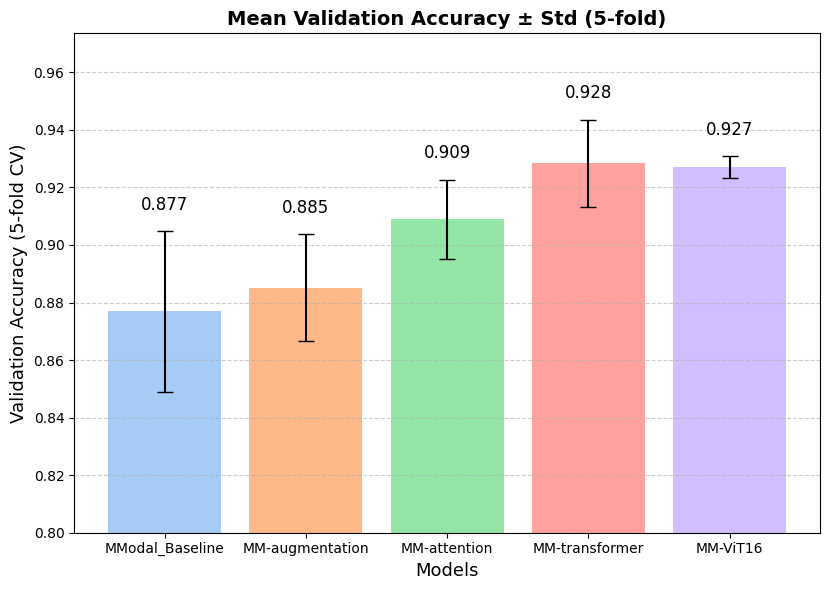

In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

excel_path = "model_statistics_all.xlsx"   # ← adjust if needed

# -------- Robust load (handles "Table 1" header rows) --------
tmp = pd.read_excel(excel_path, header=None)
rows_with_header = tmp.apply(
    lambda r: r.astype(str).str.contains(r"\bModel_ID\b", na=False, case=False, regex=True),
    axis=1
)
hdr = rows_with_header[rows_with_header].index[0]  # first row containing "Model_ID"

df = pd.read_excel(excel_path, header=hdr)
df.columns = [str(c).strip() for c in df.columns]

# -------- Columns (use the std right after the mean accuracy col) --------
mean_col = "Mean val accuracy (post-training 5fold)"
std_col  = df.columns[df.columns.get_loc(mean_col) + 1]  # the immediate next column

# Keep only rows that have the mean accuracy (one per model)
summary = df.dropna(subset=[mean_col]).copy()

# -------- Map internal names → display names & keep order --------
name_map = {
    "simple_CNN_multi":           "MModal_Baseline",
    "augmentation_CNN_multi":     "MM-augmentation",
    "att_augm_CNN_multi":         "MM-attention",
    "transformer_augm_CNN_multi": "MM-transformer",
    "ViT16_augm_CNN_multi":       "MM-ViT16",
}
model_order = ["MModal_Baseline","MM-augmentation","MM-attention","MM-transformer","MM-ViT16"]

summary["Model"] = summary["Model_Name"].replace(name_map)
summary = summary[summary["Model"].isin(model_order)]

# Convert to numeric
means = pd.to_numeric(summary[mean_col], errors="coerce")
stds  = pd.to_numeric(summary[std_col],  errors="coerce")
models = summary["Model"].tolist()

# Reorder consistently
order_idx = [models.index(m) for m in model_order if m in models]
models = [models[i] for i in order_idx]
means  = means.iloc[order_idx].values
stds   = stds.iloc[order_idx].values

# -------- Pastel colors --------
pastel_palette = {
    "MModal_Baseline": "#a1c9f4",  # pastel blue
    "MM-augmentation": "#ffb482",  # pastel orange
    "MM-attention":    "#8de5a1",  # pastel green
    "MM-transformer":  "#ff9d9a",  # pastel red
    "MM-ViT16":        "#d0bbff",  # pastel purple
}
colors = [pastel_palette[m] for m in models]

# -------- Plot --------
plt.figure(figsize=(8.4, 6))
bars = plt.bar(
    models, means, yerr=stds, capsize=6,
    color=colors, alpha=0.95, linewidth=0.8
)

# Y-limits: add headroom above the tallest error bar
top = float((means + np.nan_to_num(stds)).max())
plt.ylim(0.80, min(1.02, top + 0.03))

plt.ylabel("Validation Accuracy (5-fold CV)", fontsize=13)
plt.xlabel("Models", fontsize=13)
plt.title("Mean Validation Accuracy ± Std (5-fold)", fontsize=14, weight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Annotate each bar just above its error bar tip
for bar, acc, sd in zip(bars, means, stds):
    y = float(acc + (sd if not np.isnan(sd) else 0.0) + 0.006)  # small margin above error bar
    plt.text(
        bar.get_x() + bar.get_width()/2, y,
        f"{acc:.3f}",
        ha="center", va="bottom", fontsize=12
    )

plt.tight_layout()
plt.savefig("val_accuracy_barplot.pdf", bbox_inches="tight")
plt.savefig("val_accuracy_barplot.png", dpi=300, bbox_inches="tight")
plt.show()

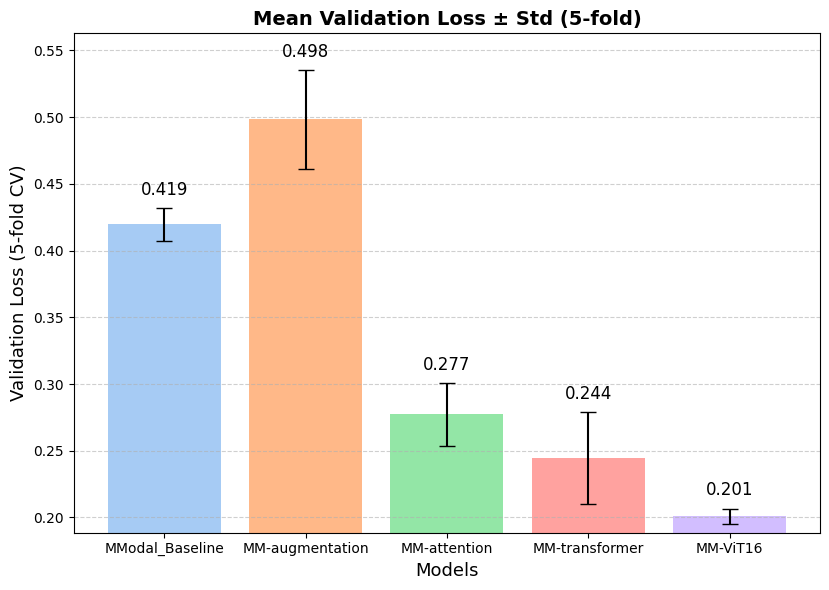

In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

excel_path = "model_statistics_all.xlsx"   # ← adjust if needed

# -------- Robust load (handles "Table 1" header rows) --------
tmp = pd.read_excel(excel_path, header=None)
rows_with_header = tmp.apply(
    lambda r: r.astype(str).str.contains(r"\bModel_ID\b", na=False, case=False, regex=True),
    axis=1
)
hdr = rows_with_header[rows_with_header].index[0]  # first row containing "Model_ID"

df = pd.read_excel(excel_path, header=hdr)
df.columns = [str(c).strip() for c in df.columns]

# -------- Columns for VALIDATION LOSS --------
loss_col     = "Mean val loss (post-training 5fold)"
loss_std_col = df.columns[df.columns.get_loc(loss_col) + 1]  # std column right after loss

# Keep only rows that have the mean val loss (one per model)
summary = df.dropna(subset=[loss_col]).copy()

# -------- Map internal names → display names & keep order --------
name_map = {
    "simple_CNN_multi":           "MModal_Baseline",
    "augmentation_CNN_multi":     "MM-augmentation",
    "att_augm_CNN_multi":         "MM-attention",
    "transformer_augm_CNN_multi": "MM-transformer",
    "ViT16_augm_CNN_multi":       "MM-ViT16",
}
model_order = ["MModal_Baseline","MM-augmentation","MM-attention","MM-transformer","MM-ViT16"]

summary["Model"] = summary["Model_Name"].replace(name_map)
summary = summary[summary["Model"].isin(model_order)]

# Convert to numeric
loss_means = pd.to_numeric(summary[loss_col],     errors="coerce")
loss_stds  = pd.to_numeric(summary[loss_std_col], errors="coerce")
models     = summary["Model"].tolist()

# Reorder consistently
order_idx  = [models.index(m) for m in model_order if m in models]
models     = [models[i] for i in order_idx]
loss_means = loss_means.iloc[order_idx].values
loss_stds  = loss_stds.iloc[order_idx].values

# -------- Pastel colors --------
pastel_palette = {
    "MModal_Baseline": "#a1c9f4",  # pastel blue
    "MM-augmentation": "#ffb482",  # pastel orange
    "MM-attention":    "#8de5a1",  # pastel green
    "MM-transformer":  "#ff9d9a",  # pastel red
    "MM-ViT16":        "#d0bbff",  # pastel purple
}
colors = [pastel_palette[m] for m in models]

# -------- Plot --------
plt.figure(figsize=(8.4, 6))
bars = plt.bar(
    models, loss_means, yerr=loss_stds, capsize=6,
    color=colors, alpha=0.95, linewidth=0.8
)

# Y-limits: start slightly below the smallest error-bar bottom, add headroom above top
bottom = float((loss_means - np.nan_to_num(loss_stds)).min())
top    = float((loss_means + np.nan_to_num(loss_stds)).max())
margin_low, margin_high = 0.02 * (top - bottom + 1e-9), 0.08 * (top - bottom + 1e-9)
plt.ylim(max(0, bottom - margin_low), top + margin_high)

plt.ylabel("Validation Loss (5-fold CV)", fontsize=13)
plt.xlabel("Models", fontsize=13)
plt.title("Mean Validation Loss ± Std (5-fold)", fontsize=14, weight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Annotate each bar just above its error bar tip
for bar, val, sd in zip(bars, loss_means, loss_stds):
    y = float(val + (sd if not np.isnan(sd) else 0.0) + 0.02*(top-bottom+1e-9))
    plt.text(
        bar.get_x() + bar.get_width()/2, y,
        f"{val:.3f}",
        ha="center", va="bottom", fontsize=12
    )

plt.tight_layout()
plt.savefig("val_loss_barplot.pdf", bbox_inches="tight")
plt.savefig("val_loss_barplot.png", dpi=300, bbox_inches="tight")
plt.show()

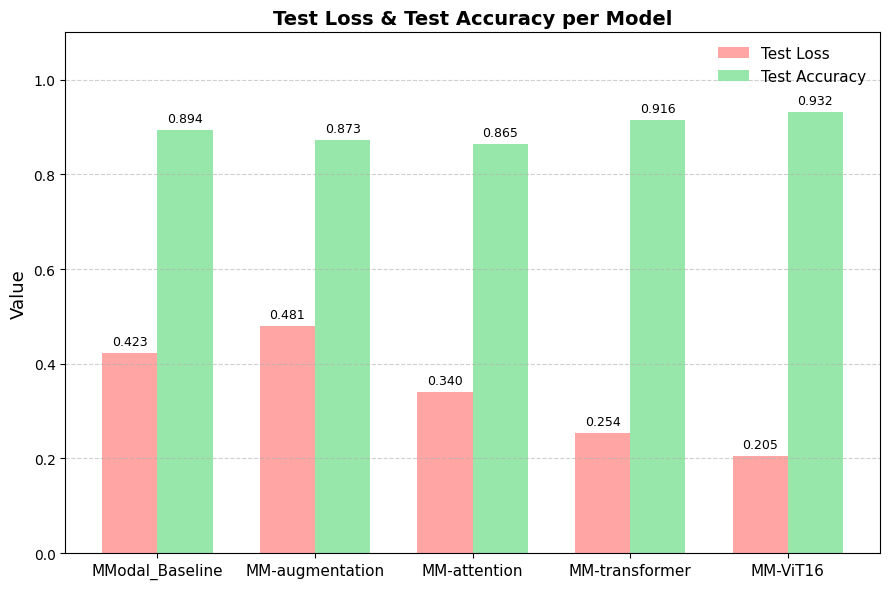

In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Data (from your sheet) ---
models = ["MModal_Baseline","MM-augmentation","MM-attention","MM-transformer","MM-ViT16"]
test_loss = [0.4231, 0.4806, 0.3399, 0.2537, 0.2055]
test_acc  = [0.8945, 0.8734, 0.865,  0.9156, 0.9325]

# --- Colors (pastel theme) ---
pastel_palette = {
    "loss": "#ff9d9a",   # pastel blue
    "acc":  "#8de5a1",   # pastel orange
}

x = np.arange(len(models))  # positions
width = 0.35                # bar width

plt.figure(figsize=(9,6))

# Bars
b1 = plt.bar(x - width/2, test_loss, width, color=pastel_palette["loss"],
             alpha=0.9, label="Test Loss")
b2 = plt.bar(x + width/2, test_acc,  width, color=pastel_palette["acc"],
             alpha=0.9, label="Test Accuracy")

# Annotate values on top
for bar in b1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
for bar in b2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

# Axes + styling
plt.xticks(x, models, fontsize=11)
plt.ylabel("Value", fontsize=13)
plt.title("Test Loss & Test Accuracy per Model", fontsize=14, weight="bold")
plt.ylim(0, 1.1)  # since accuracy ~0.9 and loss <0.5
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.legend(frameon=False, fontsize=11, loc="upper right")
plt.tight_layout()
plt.savefig("test_loss_acc_barplot.pdf", bbox_inches="tight")
plt.savefig("test_loss_acc_barplot.png", dpi=300, bbox_inches="tight")
plt.show()